# Stage 12 — Results Reporting & Delivery Design

Stakeholder-ready delivery of the **Hobby Box EV Calculator**. Charts + tables are saved to `reports/images/` and `data/processed/`; the memo lives in `reports/stakeholder_report.md`.

In [5]:
# --- packages: uncomment once, then re-comment ---
# !pip install numpy pandas matplotlib seaborn

## Executive Summary

**Headline: at today's prices, only 1 of the 6 sealed hobby boxes is a positive-EV buy (NBA Hoops Hobby, EV/$ ≈ 1.1); the two hyped premium boxes (Chrome Update, Cosmic Chrome, ~$1,100) return roughly $0.20 of card value per $1 paid.**

- EV = probability-weighted resale value of a box's contents (`src/ev.py`), compared to its street price. `EV/$ > 1` = good bet over many boxes; `< 1` = pay-to-play.
- The buy/pass verdict is **robust**: doubling our (placeholder) card values still leaves every premium box below break-even, and how we impute missing pull-odds does not move the value model.
- Biggest caveat: card values are a `rough_estimate_v0` ladder (only 6 real eBay comps so far) — treat absolute EV as indicative, the *ranking* as reliable.

In [6]:
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(_root))
from src import ev

sns.set(style='whitegrid'); plt.rcParams['figure.dpi'] = 120
np.random.seed(101)

## Build results

`ev.ev_table()` = every box config with EV, price, and the `EV/$` and `EV/pack` ratios. Saved to `data/processed/ev_report.csv`.

In [7]:
evdf = ev.ev_table()
(_root / 'data' / 'processed').mkdir(parents=True, exist_ok=True)
evdf.to_csv(_root / 'data' / 'processed' / 'ev_report.csv', index=False)

priced = evdf.dropna(subset=['ev_per_price']).copy()
hobby = evdf[evdf['box_format'] == 'Hobby'].copy()
print(f"{len(evdf)} box configs | {len(priced)} with a price | "
      f"{(priced['ev_per_price'] >= 1).sum()} are positive-EV (EV/$ >= 1)")
evdf.head(10)

29 box configs | 24 with a price | 3 are positive-EV (EV/$ >= 1)


,product,line,box_format,channel,packs,ev,srp,retail,price,ev_per_price,ev_per_pack,basis
0,2025-26 Bowman Basketball Jumbo,2025-26 Bowman Basketball,Jumbo,hobby,12.0,756.80,599.99,599.99,599.99,1.261,63.07,autos+ssp+base
1,2025-26 Topps NBA Hoops Hobby,2025-26 Topps NBA Hoops,Hobby,hobby,20.0,290.24,279.99,259.95,259.95,1.117,14.51,tier_ladder
2,2025-26 Topps NBA Hoops Jumbo,2025-26 Topps NBA Hoops,Jumbo,hobby,10.0,539.60,519.99,519.99,519.99,1.038,53.96,autos+ssp+base
3,2025-26 Bowman Basketball Mega,2025-26 Bowman Basketball,Mega,retail,6.0,43.36,59.99,59.99,59.99,0.723,7.23,autos+ssp+base
4,2025-26 Topps Chrome Basketball Hobby,2025-26 Topps Chrome Basketball,Hobby,hobby,20.0,218.50,379.99,379.99,379.99,0.575,10.93,tier_ladder
5,2025-26 Topps Chrome Basketball Jumbo,2025-26 Topps Chrome Basketball,Jumbo,hobby,12.0,401.03,699.99,699.99,699.99,0.573,33.42,autos+ssp+base
6,2025-26 Topps Signature Class Basketball Jumbo,2025-26 Topps Signature Class Basketball,Jumbo,hobby,4.0,407.20,899.99,899.99,899.99,0.452,101.80,autos+ssp+base
7,2025-26 Bowman Basketball Value Blaster,2025-26 Bowman Basketball,Value Blaster,retail,6.0,12.00,29.99,29.99,29.99,0.400,2.00,autos+ssp+base
8,2025-26 Topps Signature Class Basketball Hobby,2025-26 Topps Signature Class Basketball,Hobby,hobby,8.0,183.01,549.99,549.99,549.99,0.333,22.88,tier_ladder
9,2025-26 Topps Chrome Update Series Basketball ...,2025-26 Topps Chrome Update Series Basketball,Jumbo,hobby,12.0,363.25,1099.99,1099.99,1099.99,0.330,30.27,autos+ssp+base


## Export helper

In [8]:
img_dir = _root / 'reports' / 'images'
img_dir.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.tight_layout()
    plt.savefig(img_dir / name, dpi=300, bbox_inches='tight')
    print('saved', name)

## Chart 1 — EV vs. retail price (the buy/pass picture)

Each point is one sealed box. Points **above** the dashed break-even line are positive-EV; points **below** mean you pay more than the contents are worth.

saved ev_vs_price.png


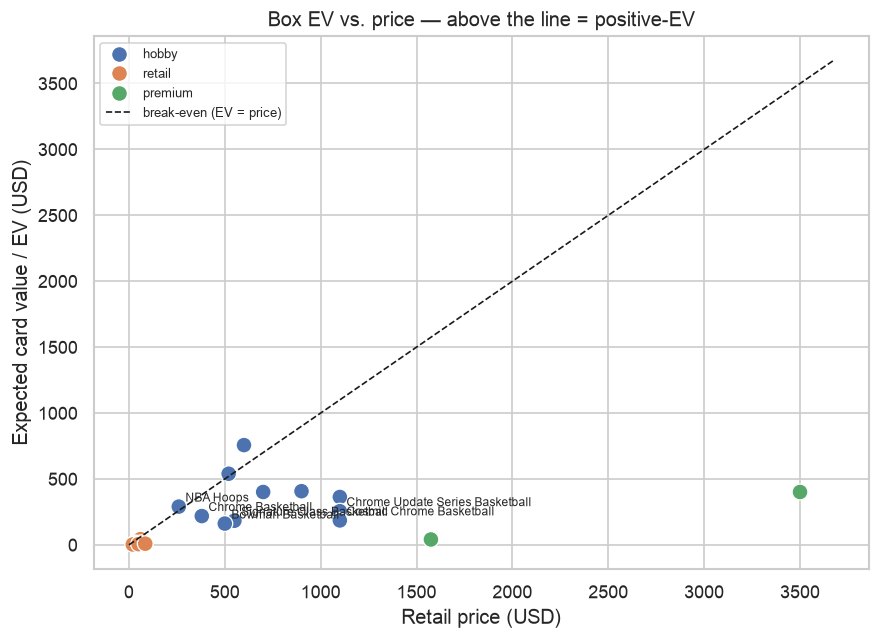

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.scatterplot(data=priced, x='price', y='ev', hue='channel', s=90, ax=ax)
lim = priced['price'].max() * 1.05
ax.plot([0, lim], [0, lim], ls='--', color='k', lw=1, label='break-even (EV = price)')
for _, r in priced.iterrows():
    if r['box_format'] == 'Hobby':
        ax.annotate(r['line'].replace('2025-26 Topps ', '').replace('2025-26 ', ''),
                    (r['price'], r['ev']), fontsize=7, xytext=(4, 3),
                    textcoords='offset points')
ax.set_xlabel('Retail price (USD)'); ax.set_ylabel('Expected card value / EV (USD)')
ax.set_title('Box EV vs. price — above the line = positive-EV')
ax.legend(fontsize=8)
savefig('ev_vs_price.png'); plt.show()

## Chart 2 — EV/$ ratio by box config

`EV / price`. Green = at or above break-even; grey = pay-to-play. Sorted best to worst.

saved ev_per_dollar.png


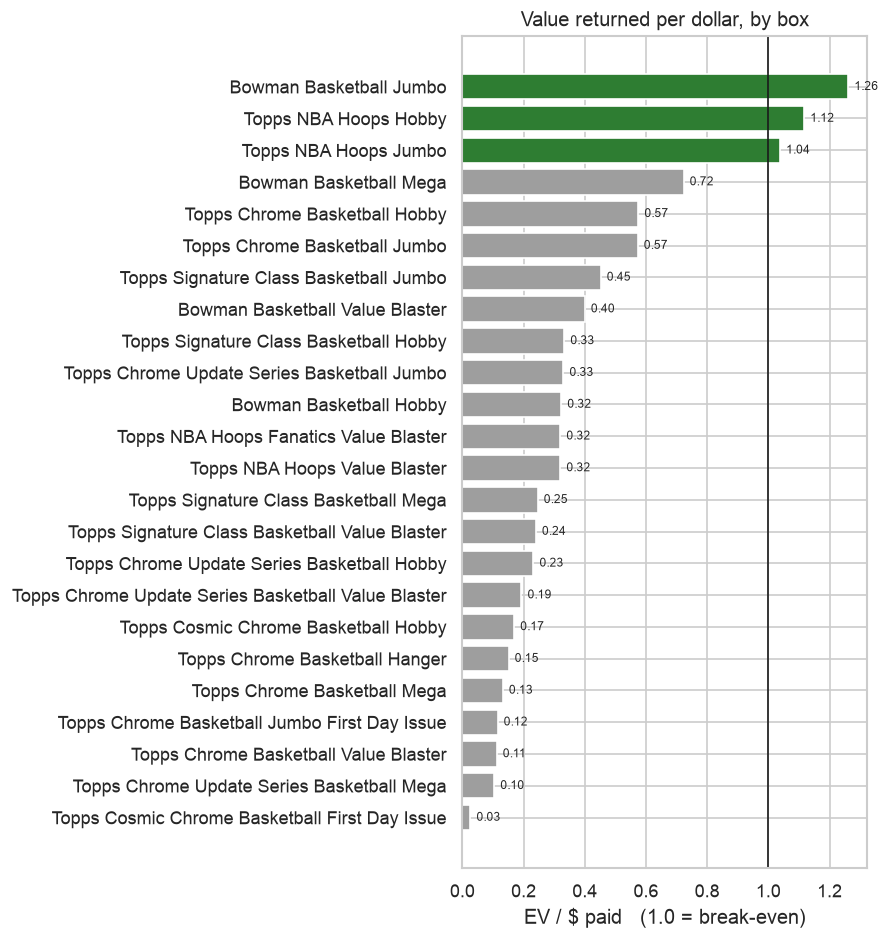

In [10]:
d = priced.sort_values('ev_per_price')
colors = ['#2e7d32' if v >= 1 else '#9e9e9e' for v in d['ev_per_price']]
fig, ax = plt.subplots(figsize=(7.5, 8))
ax.barh(d['product'].str.replace('2025-26 ', ''), d['ev_per_price'], color=colors)
ax.axvline(1.0, color='k', lw=1)
ax.set_xlabel('EV / $ paid   (1.0 = break-even)')
ax.set_title('Value returned per dollar, by box')
for i, v in enumerate(d['ev_per_price']):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=7)
savefig('ev_per_dollar.png'); plt.show()

## Chart 3 — Sensitivity: does the verdict survive our biggest assumption?

Card values are a placeholder ladder. Re-price the 6 hobby boxes assuming card values are **half**, **as-is**, or **double** our estimate (EV scales ~linearly). If the buy/pass call flips, the result is fragile.

saved sensitivity_values.png


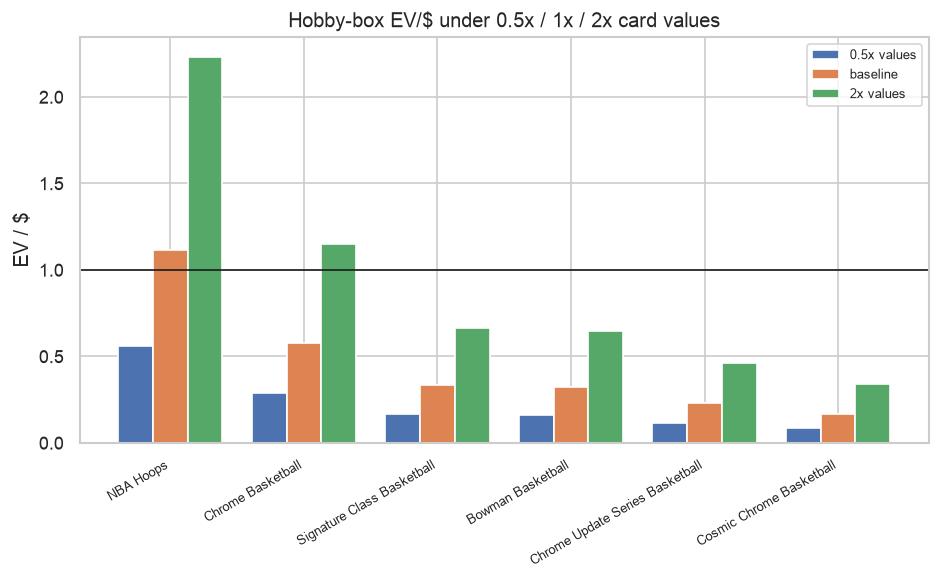

,box,EV/$ @0.5x,EV/$ baseline,EV/$ @2x
0,NBA Hoops,0.56,1.12,2.23
1,Chrome Basketball,0.29,0.57,1.15
2,Signature Class Basketball,0.17,0.33,0.67
3,Bowman Basketball,0.16,0.32,0.65
4,Chrome Update Series Basketball,0.12,0.23,0.46
5,Cosmic Chrome Basketball,0.08,0.17,0.34


In [11]:
labels = hobby['line'].str.replace('2025-26 Topps ', '').str.replace('2025-26 ', '')
base = hobby['ev_per_price'].values
mults = {'0.5x values': 0.5, 'baseline': 1.0, '2x values': 2.0}
x = np.arange(len(hobby)); w = 0.26
fig, ax = plt.subplots(figsize=(8, 5))
for i, (name, m) in enumerate(mults.items()):
    ax.bar(x + (i - 1) * w, base * m, w, label=name)
ax.axhline(1.0, color='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('EV / $'); ax.set_title('Hobby-box EV/$ under 0.5x / 1x / 2x card values')
ax.legend(fontsize=8)
savefig('sensitivity_values.png'); plt.show()

sens_view = pd.DataFrame({'box': labels.values,
                          'EV/$ @0.5x': (base*0.5).round(2),
                          'EV/$ baseline': base.round(2),
                          'EV/$ @2x': (base*2).round(2)})
sens_view

## Assumptions & Risks

In [12]:
assump = pd.DataFrame([
  dict(assumption='Card values = rough_estimate_v0 ladder (6 real eBay comps)',
       baseline='EV as reported',
       alternate='x0.5 / x2 card values',
       effect_on_decision='Premium boxes stay PASS even at x2; NBA Hoops stays BUY even at x0.5 -> ranking robust, absolute EV is indicative'),
  dict(assumption='Missing pull-odds imputed by column mean',
       baseline='value-model slope 0.669',
       alternate='median / drop  (data/processed/scenario_results.csv)',
       effect_on_decision='slope 0.669 / 0.670 / 0.669 -> no change'),
  dict(assumption='EV is a mean; box outcomes are right-skewed',
       baseline='report EV', alternate='report median / P(beat price)',
       effect_on_decision='most boxes return BELOW EV; only buy when EV/$ is comfortably >1, not marginally'),
  dict(assumption='Non-Hobby EV omits the parallel rainbow',
       baseline='autos+SSP+base only', alternate='full tier ladder (not yet transcribed)',
       effect_on_decision='non-Hobby EV/$ shown are LOWER BOUNDS; true values modestly higher'),
  dict(assumption='Prices are one street-price snapshot (2026-08-28)',
       baseline='blowoutcards / SRP', alternate='live market feed',
       effect_on_decision='hot-box prices move weekly; re-run before acting'),
])
assump.to_csv(_root / 'data' / 'processed' / 'assumptions_risks.csv', index=False)
assump

,assumption,baseline,alternate,effect_on_decision
0,Card values = rough_estimate_v0 ladder (6 real...,EV as reported,x0.5 / x2 card values,Premium boxes stay PASS even at x2; NBA Hoops ...
1,Missing pull-odds imputed by column mean,value-model slope 0.669,median / drop (data/processed/scenario_result...,slope 0.669 / 0.670 / 0.669 -> no change
2,EV is a mean; box outcomes are right-skewed,report EV,report median / P(beat price),most boxes return BELOW EV; only buy when EV/$...
3,Non-Hobby EV omits the parallel rainbow,autos+SSP+base only,full tier ladder (not yet transcribed),non-Hobby EV/$ shown are LOWER BOUNDS; true va...
4,Prices are one street-price snapshot (2026-08-28),blowoutcards / SRP,live market feed,hot-box prices move weekly; re-run before acting


## Interpretations / Takeaways

- **Chart 1:** only **NBA Hoops Hobby** ($260, EV ≈ $290) sits above break-even among hobby boxes; **Bowman Jumbo** and **Hoops Jumbo** are marginal (EV/$ ≈ 1.0-1.3, and these are lower-bound estimates). Every other box sits well below the line.
- **Chart 2:** the two most-hyped boxes — **Chrome Update** and **Cosmic Chrome** Hobby, both ~$1,100 — return **EV/$ ≈ 0.17-0.23**: about $1 of card value for every $5 paid. You are buying the Cooper-Flagg lottery ticket, not the expected contents.
- **Chart 3:** halving or doubling our card-value estimate **does not flip a single verdict** — premium boxes stay 'pass', NBA Hoops stays 'buy'. The recommendation is not an artifact of shaky value placeholders.
- The Stage 11 sensitivity table confirms the value model's slope (≈ 0.67: '10x rarer ≈ 4.7x more valuable') is unchanged across mean / median / drop imputation.

## Decision Implications

**For the collector (the stakeholder):**
- **Buy:** NBA Hoops Hobby at/below ~$260 is the only sealed box that clears break-even on expected contents.
- **Pass (as an EV play):** Chrome Update, Cosmic Chrome, Signature Class, Bowman, Chrome — all return < $0.60 per $1 at current prices. Only buy these for the rip experience or a specific chase card, with eyes open.
- **Avoid entirely on EV:** retail Blaster / Mega / Hanger and the Chrome Jumbo **First Day Issue** ($3,500, EV/$ ≈ 0.11) — you are paying a large premium for the stamp, not the cards.
- Subtract **~13% selling fees** before treating any EV/$ ≈ 1 box as profitable.

**Next steps for the tool:**
1. Replace the placeholder card ladder with real eBay sold-comp medians (`data/raw/tier_comps.csv`) — tightens absolute EV; prioritise autographs and low-numbered parallels.
2. Transcribe per-format tier odds so non-Hobby EV stops being a lower bound.
3. Wire a weekly price refresh so `EV/$` tracks the live market.
4. Add `P(box beats price)` and median outcome alongside EV, since the mean hides the right-skew.